In [24]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

Getting [0...1] bitmap from image


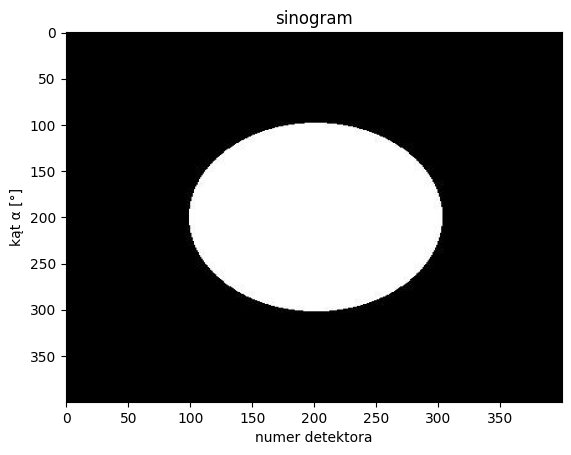

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [ ]:
img = Image.open("img/Kolo.jpg")

plt.imshow(img, aspect='auto')
plt.title('obraz wejściowy')
plt.show()

grayscale_img = img.convert("L")

bitmap = np.array(grayscale_img)/255
print(bitmap)

Algorytm Bresenhama


In [26]:
def Breshenham(x0,y0,x1,y1):
    points = []
    
    delta_x = abs(x1 - x0)
    delta_y = abs(y1 - y0)
    
    direction_x = 1 if x0 < x1 else -1
    direction_y = 1 if y0 < y1 else -1
    
    error = delta_x - delta_y

    while True:
        points.append((x0, y0))
        
        if x0 == x1 and y0 == y1:
            break
            
        error_x2 = 2 * error
        
        #horizontal move
        if error_x2 > -delta_y:
            error -= delta_y
            x0 += direction_x
            
        #vertical mvoe
        if error_x2 < delta_x:
            error += delta_x
            y0 += direction_y
            
    return points

definiowanie wartosci


In [27]:
H, W = bitmap.shape
cx, cy = (W - 1) / 2.0, (H - 1) / 2.0
R = min(W, H) / 2.0

n_detektorow = 180
delta_alpha  = 1.0   # krok kąta w stopniach
angles       = np.arange(0, 180, delta_alpha)       # [0, 1, 2, ..., 179]
offsets      = np.linspace(-R, R, n_detektorow)     # pozycje detektorów

sinogram = np.zeros((len(angles), n_detektorow))

wyznaczanie sinogramu


In [28]:
for i, alpha_deg in enumerate(angles):
    alpha = np.radians(alpha_deg)
    cos_a, sin_a = np.cos(alpha), np.sin(alpha)
    dx_p, dy_p   = -sin_a, cos_a          # oś prostopadła (gdzie siedzą detektory)

    for j, offset in enumerate(offsets):
        # środek tej konkretnej wiązki
        mx = cx + offset * dx_p
        my = cy + offset * dy_p

        # przedłuż wiązkę poza obraz
        t  = max(W, H)
        x0 = int(round(mx - t * cos_a))
        y0 = int(round(my - t * sin_a))
        x1 = int(round(mx + t * cos_a))
        y1 = int(round(my + t * sin_a))

        # zsumuj pochłonięcie wzdłuż wiązki → jedna komórka sinogramu
        piksele = Breshenham(x0, y0, x1, y1)

        sinogram[i, j] = sum(
            bitmap[py, px]
            for px, py in piksele
            if 0 <= px < W and 0 <= py < H   # ← filtruj punkty poza obrazem
        )

sinogram /= sinogram.max()

Sinogram

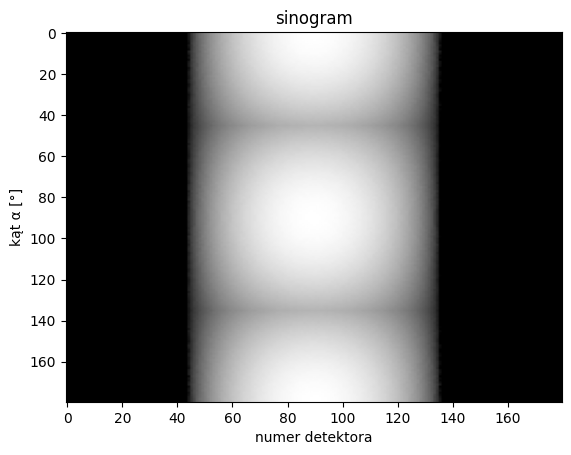

In [29]:
plt.imshow(sinogram, cmap='gray', aspect='auto')
plt.xlabel('numer detektora')
plt.ylabel('kąt α [°]')
plt.title('sinogram')
plt.show()